In [11]:
from openai import OpenAI

from app import MAIN_AGENT_SYSTEM_PROMPT
from app import ALL_AGENTS_MODEL_NAME

In [3]:
from dotenv import load_dotenv
import os

load_dotenv()  # Loads variables from .env

openai_key = os.getenv("OPENAI_API_KEY")
print(openai_key[:5])  # Just to check, don't print the full key!

sk-pr


In [4]:
client = OpenAI()

Sanity check - running the model with user content which includes the history and the latest user input

In [5]:
history_text = """Recruiter: Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?
Candidate: I've been using Python professionally for five years, mostly for data analysis.
Recruiter: Our engineering manager can interview you Wednesday at 10 AM or Thursday at 2 PM. Which works best?"""

latest_input = "I can't at that time—I'm busy."

response = client.responses.create(
    model=ALL_AGENTS_MODEL_NAME,
    input=[
        {"role": "system", "content": MAIN_AGENT_SYSTEM_PROMPT},
        {
            "role": "user",
            "content": f"""Conversation history:
{history_text}

Latest candidate message:
{latest_input}"""
        },
    ],
)

print(response.output_text)

schedule


Recieved label is as expected according to the label recieved for this input in the conversation -> schedule

A script for creating jsonl file for evaluation from the sms_conversations

In [6]:
import json

def convert_to_eval_jsonl(input_path, output_path):
    with open(input_path, "r") as f:
        data = json.load(f)

    items = []

    for conv in data:
        turns = conv["turns"]

        history = []

        for i, turn in enumerate(turns):
            speaker = turn["speaker"]
            text = turn["text"]

            if speaker == "candidate":
                # find next recruiter turn
                next_label = None
                for j in range(i + 1, len(turns)):
                    if turns[j]["speaker"] == "recruiter":
                        next_label = turns[j]["label"]
                        break

                if next_label is None:
                    continue

                history_text = "\n".join(history)

                items.append({
                    "item": {
                        "conversation_history": history_text,
                        "latest_user_input": text,
                        "correct_label": next_label
                    }
                })

            # add current turn to history
            role = "Recruiter" if speaker == "recruiter" else "Candidate"
            history.append(f"{role}: {text}")

    # write JSONL
    with open(output_path, "w") as f:
        for item in items:
            f.write(json.dumps(item) + "\n")

# usage
convert_to_eval_jsonl("sms_conversations.json", "eval_dataset.jsonl")

In [7]:
eval_dataset_file_obj_in_openai = client.files.create(
    file=open("eval_dataset.jsonl", "rb"),
    purpose="evals"
)


print(eval_dataset_file_obj_in_openai)
print(eval_dataset_file_obj_in_openai.id)

FileObject(id='file-MnwpuCR1YD698m3GLRYqrA', bytes=19688, created_at=1775901791, filename='eval_dataset.jsonl', object='file', purpose='evals', status='processed', expires_at=None, status_details=None)
file-MnwpuCR1YD698m3GLRYqrA


In [8]:
eval_obj_recruiting_main_agent_label = client.evals.create(

    name="Recruiting Main Agent Routing",


    data_source_config={
        "type": "custom",
        "item_schema": {
            "type": "object",
            "properties": {
                "conversation_history": {"type": "string"},
                "latest_user_input": {"type": "string"},
                "correct_label": {"type": "string"},
            },
            "required": ["conversation_history", "latest_user_input", "correct_label"],
        },
        "include_sample_schema": True,


    },
    testing_criteria=[
        {
            "type": "string_check",
            "name": "Match output to human label",
            "input": "{{ sample.output_text }}",
            "operation": "eq",
            "reference": "{{ item.correct_label }}",
        }
    ],
)


print(eval_obj_recruiting_main_agent_label)
print(eval_obj_recruiting_main_agent_label.id)

EvalCreateResponse(id='eval_69da1ccc22b881919c8d94dc7ef9bc53', created_at=1775901900, data_source_config=EvalCustomDataSourceConfig(schema_={'type': 'object', 'properties': {'item': {'type': 'object', 'properties': {'conversation_history': {'type': 'string'}, 'latest_user_input': {'type': 'string'}, 'correct_label': {'type': 'string'}}, 'required': ['conversation_history', 'latest_user_input', 'correct_label']}, 'sample': {'type': 'object', 'properties': {'model': {'type': 'string'}, 'choices': {'type': 'array', 'items': {'type': 'object', 'properties': {'message': {'type': 'object', 'properties': {'role': {'type': 'string', 'enum': ['assistant']}, 'content': {'type': ['string', 'array', 'null']}, 'refusal': {'type': ['boolean', 'null']}, 'tool_calls': {'type': ['array', 'null'], 'items': {'type': 'object', 'properties': {'type': {'type': 'string', 'enum': ['function']}, 'function': {'type': 'object', 'properties': {'name': {'type': 'string'}, 'arguments': {'type': 'string'}}, 'require

In [21]:
run = client.evals.runs.create(
    eval_id=eval_obj_recruiting_main_agent_label.id,
    name="main-agent-routing-run",
    data_source={
        "type": "completions",
        "source": {
            "type": "file_id",
            "id": eval_dataset_file_obj_in_openai.id,
        },
        "model": ALL_AGENTS_MODEL_NAME,
        "input_messages": {
            "type": "template",
            "template": [
                {
                    "role": "system",
                    "content": MAIN_AGENT_SYSTEM_PROMPT,
                },
                {
                    "role": "user",
                    "content": "Conversation history:\n{{ item.conversation_history }}\n\nLatest candidate message:\n{{ item.latest_user_input }}",
                },
            ],
        },
    },
)

In [22]:
run_retrieve = client.evals.runs.retrieve(
    eval_id=eval_obj_recruiting_main_agent_label.id, # YOUR_EVAL_ID
    run_id=run.id # YOUR_RUN_ID
    )


print(run_retrieve)
print(run_retrieve.status)

RunRetrieveResponse(id='evalrun_69dc7e20d3048191b50d009609239905', created_at=1776057888, data_source=CreateEvalCompletionsRunDataSource(source=SourceFileID(id='file-MnwpuCR1YD698m3GLRYqrA', type='file_id'), type='completions', input_messages=InputMessagesTemplate(template=[EasyInputMessage(content='You are a decision-making assistant in a recruitment conversation for a Python Developer role.\n\nYour job is to determine the next immediate stage of the conversation based on the dialogue so far.\n\nYou must return EXACTLY ONE of the following labels:\n- continue\n- schedule\n- end\n\nDo not return anything else.\nDo not explain your reasoning.\nDo not generate a message to the user.\n\n----------------------------------------\nMEANING OF LABELS\n----------------------------------------\n\n1. CONTINUE\nReturn "continue" when the conversation still needs clarification, information gathering, or evaluation of the candidate\'s background, skills, or fit.\nThis includes cases where:\n- more i

### Accuracy

In [23]:
passed = run_retrieve.result_counts.passed
total = run_retrieve.result_counts.total

print('Accuracy')
print(len('Accuracy')*'-')
print(f'{(passed / total) :.2%}')

Accuracy
--------
59.09%


### Metrics

In [24]:
items = client.evals.runs.output_items.list(
    eval_id=eval_obj_recruiting_main_agent_label.id, # EVAL_ID
    run_id=run.id # RUN_ID
    )

True Labes vs. Predicted Labels

In [25]:
# Extract ground truth and predictions
y_true = [item.datasource_item['correct_label'] for item in items]
y_pred = [item.sample.output[0].content.strip() for item in items]


print(f'true labels: {y_true}')
print(f'predicted labels: {y_pred}')

true labels: ['schedule', 'end', 'continue', 'schedule', 'end', 'end', 'schedule', 'schedule', 'end', 'schedule', 'schedule', 'schedule', 'schedule', 'end', 'end', 'continue', 'schedule', 'end', 'end', 'end', 'continue', 'continue', 'end', 'schedule', 'schedule', 'schedule', 'schedule', 'continue', 'schedule', 'end', 'end', 'continue', 'schedule', 'schedule', 'continue', 'schedule', 'end', 'end', 'continue', 'end', 'schedule', 'continue', 'continue', 'schedule']
predicted labels: ['continue', 'end', 'continue', 'continue', 'end', 'end', 'continue', 'schedule', 'schedule', 'schedule', 'end', 'continue', 'schedule', 'end', 'schedule', 'continue', 'schedule', 'end', 'end', 'schedule', 'continue', 'continue', 'schedule', 'continue', 'continue', 'continue', 'schedule', 'continue', 'continue', 'schedule', 'end', 'continue', 'continue', 'continue', 'continue', 'schedule', 'end', 'end', 'continue', 'schedule', 'schedule', 'continue', 'continue', 'continue']


Calculated Accuracy according to Accuracy Score

In [26]:
from sklearn.metrics import accuracy_score

# Compute metrics accuracy_score
print('accuracy_score')
print(accuracy_score(y_true, y_pred))

accuracy_score
0.5909090909090909


### Confusion Matrix

In [27]:
from sklearn.metrics import confusion_matrix
import pandas as pd

labels = sorted(set(y_true) | set(y_pred))

cm = confusion_matrix(y_true, y_pred, labels=labels)

df_cm = pd.DataFrame(cm, index=labels, columns=labels)
print("Confusion Matrix:\n")
print(df_cm)

Confusion Matrix:

          continue  end  schedule
continue        10    0         0
end              0    9         6
schedule        11    1         7


In [28]:
import numpy as np

for idx, label in enumerate(labels):
    TP = cm[idx, idx]
    FP = cm[:, idx].sum() - TP
    FN = cm[idx, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    print(f"\nLabel: {label}")
    print(f"  TP: {TP}")
    print(f"  FP: {FP}")
    print(f"  FN: {FN}")
    print(f"  TN: {TN}")


Label: continue
  TP: 10
  FP: 11
  FN: 0
  TN: 23

Label: end
  TP: 9
  FP: 1
  FN: 6
  TN: 28

Label: schedule
  TP: 7
  FP: 6
  FN: 12
  TN: 19


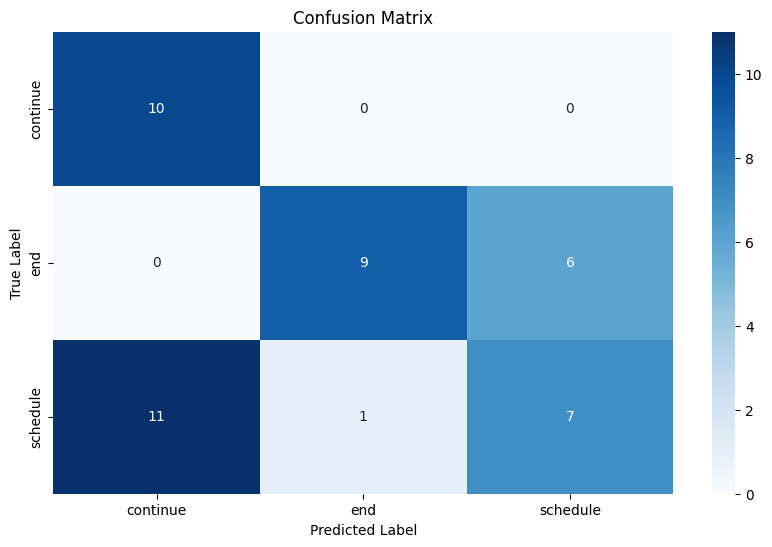

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df_cm, annot=True, fmt='d', cmap="Blues")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

We can see that we got many mismatches of 'end' and 'schedule' true lables that were predicted as 'continue'.
It looks like the main agent model is over trying to keep engagement with the candidate and does not move fast enough to schedule an interview which is also supposed to lead to end the conversarion faster (therefore mismatches of schedule instead of end, the schedule phase is reached too late in the conversation).

According to conversations iterations, it looks like the recruiter's routing (label) and responses are not always natural, as sometimes the recruiter rushes to propose an interview for the candidate without assuring that the candidate has all the required experience.
We can assume that there is an earlier knowledge by the recruiter, like a resume that was uploaded or a multiple selection phase which gathered information about the candidate prior to engaging in a conversation.

Ways for improving accuracy:
- Adjusting system prompt for the main agent to be more proactive in proposing an interview.

- Few Shot Learning - with few shot learning, the desired scenarios will be clearer for the model and it will probably set the interview faster and therefore will also get to 'end' faster.

- Fine tuning for the main agent model using 80% or all of the dataset.

- Changing the design so that the orchestration can change the original label returned by the main agent, according to the sub agents responses. If the label is reevaluated, like after info agent responding that the user has enough experience, then at the same turn we can already get to 'schedule', then getting faster to 'end'.
The reason for the current design of the main agent setting the final and inchanagble value of the label, is in order for us to be able to test the labeling behavior according to the main agent model only, in order to use the OpenAI evaluation capabilities.
For other designs using multi stages labeling orchestration, a manual accuracy testing can be done, by calling locally the orchestration method, and comparing the recieved labels returned form it to the true labels. 